In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from collections import defaultdict
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

def load_all(data_dir):
    seeds = os.listdir(os.path.join(data_dir, PROCESSED_DIR))

    all_renders = {}
    gts = {}
    preds = {seed: {} for seed in seeds}
    for renders_file in tqdm(glob.glob(os.path.join(data_dir, RENDERS_DIR, '*.npz'))):
        dp_name = os.path.splitext(os.path.basename(renders_file))[0]
    
        all_renders[dp_name] = np.load(renders_file)
    
        try:
            with open(os.path.join(data_dir, TRUE_STATES_DIR, dp_name + '.json'), 'r') as f:
                gts[dp_name] = json.load(f)
        except FileNotFoundError:
            pass
    
        for seed in seeds:
            try:
                with open(os.path.join(data_dir, PROCESSED_DIR, str(seed), dp_name + '.json'), 'r') as f:
                    preds[seed][dp_name] = json.load(f)
                first_item = next(iter(preds[seed][dp_name].values()))
                if isinstance(first_item, dict):
                    means = defaultdict(int)
                    num_viewpoints = len(preds[seed][dp_name])
                    for k, v in  preds[seed][dp_name].items():
                        preds.setdefault(seed + ' ' + k, {})[dp_name] = v
                        for predicate, score in v.items():
                            means[predicate] += score / num_viewpoints
                    preds[seed][dp_name] = means
            except FileNotFoundError:
                pass

    return all_renders, gts, preds

all_renders, gts, preds = load_all('examples/gw_grip/data_dir')

  0%|          | 0/2000 [00:00<?, ?it/s]

In [2]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score
)
import numpy as np
from itertools import combinations

from semantic_state_estimator.utils.statistics import acc_curve_with_cooc_mat, ap_score_with_cooc_mat
from semantic_state_estimator.utils.misc import squash_predicate


def collect_metrics(ground_truths, predicted_scores, cooc_mat=None, ignore_for_prec=None):
    ignore_for_prec = ignore_for_prec or []
    
    # sqash to array format
    y = squash_predicate({k: v for k, v in ground_truths.items() if k in predicted_scores})
    y_score = squash_predicate(predicted_scores)

    # map predicates in alphabetical order for consistency
    pred_to_idx = {pred: i for i, pred in enumerate(sorted(next(iter(ground_truths.values()))))}

    # instantiate output containters
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {},
    thresh_cooc = {}
    ap_cooc = {}

    # iterate predicates
    for pred, i in pred_to_idx.items():
        if pred in ignore_for_prec:
            precision[pred], recall[pred], thresholds[pred] = [], [], []
            average_precision[pred] = np.nan
        else:
            precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y[:, i], y_score[:, i])
            average_precision[pred] = average_precision_score(y[:, i], y_score[:, i])
            thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back

    # accuracy (based on accuracy score from sklearn) curve and my custom AP implementation
    accuracy, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100)
    if cooc_mat is not None:
        # only need this for comparison if using cooccurrence
        ap, prec, rec, thresh = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, ignored_keys=ignore_for_prec)

        acc_cooc, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat)
        ap_cooc, prec_cooc, rec_cooc, thresh_cooc = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat,
                                                                           ignored_keys=ignore_for_prec)

    for key in ignore_for_prec:
        np.delete(y, pred_to_idx[key], axis=1)
    # average_precision['macro average'] = average_precision_score(y, y_score, average='macro')  # compatible only with numbered lasses
    average_precision['micro average'] = average_precision_score(y.flatten(), y_score.flatten(), average='micro')
    average_precision['macro average'] = np.mean(list(average_precision.values()))

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

def collect_metrics_all_models(ground_truths, predicted_scores_all_models, cooc_mat=None, ignore_for_prec=None):
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {}
    thresh_cooc = {}
    ap_cooc = {}
    
    for model, predicted_scores in tqdm(predicted_scores_all_models.items()):
        (
            accuracy[model],
            precision[model],
            recall[model],
            thresholds[model],
            average_precision[model],
            prec[model],
            rec[model],
            thresh[model],
            ap[model],
            acc_cooc[model],
            prec_cooc[model],
            rec_cooc[model],
            thresh_cooc[model],
            ap_cooc[model]
        ) = collect_metrics(ground_truths, predicted_scores, cooc_mat, ignore_for_prec)

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

In [3]:
from semantic_state_estimator.utils.statistics import get_cooccurrence_matrix
cooc_mat = None#get_cooccurrence_matrix('stam')

In [4]:
(
    accuracy,
    precision,
    recall,
    thresholds,
    average_precision,
    prec,
    rec,
    thresh,
    ap,
    acc_cooc,
    prec_cooc,
    rec_cooc,
    thresh_cooc,
    ap_cooc
) = collect_metrics_all_models(gts, preds, cooc_mat)

  0%|          | 0/30 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

...

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

In [5]:
all_renders_home, gts_home, preds_home = load_all('examples/gw_grip_home/data_dir')

  0%|          | 0/2000 [00:00<?, ?it/s]

In [6]:
(
    accuracy_home,
    precision_home,
    recall_home,
    thresholds_home,
    average_precision_home,
    prec_home,
    rec_home,
    thresh_home,
    ap_home,
    acc_cooc_home,
    prec_cooc_home,
    rec_cooc_home,
    thresh_cooc_home,
    ap_cooc_home
) = collect_metrics_all_models(gts_home, preds_home, cooc_mat)

  0%|          | 0/30 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

...

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

In [7]:
metrics_dict = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'thresholds': thresholds,
    'average_precision': average_precision,
    'prec': prec,
    'rec': rec,
    'thresh': thresh,
    'ap': ap,
    'acc_cooc': acc_cooc,
    'prec_cooc': prec_cooc,
    'rec_cooc': rec_cooc,
    'thresh_cooc': thresh_cooc,
    'ap_cooc': ap_cooc
}

for metric_name, metric in tqdm(metrics_dict.items()):
    equivalent_home_metric = eval(f'{metric_name}_home')
    for key, value in equivalent_home_metric.items():
        metric[key + ' + Pose'] = value

  0%|          | 0/14 [00:00<?, ?it/s]

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

sns.set_theme()
colors = list(sns.color_palette())

displayed_models = ['0.5B',
                    '7B',
                    '72B',
                    '0.5B + Pose',
                    '7B + Pose',
                    '72B + Pose',
                    '72B + Instruct + Pose',
                    '72B + Instruct-milk + Pose',
                    '7B + Instruct + Pose',
                    '7B + Instruct-milk + Pose']

color_map = dict(zip(displayed_models, colors))

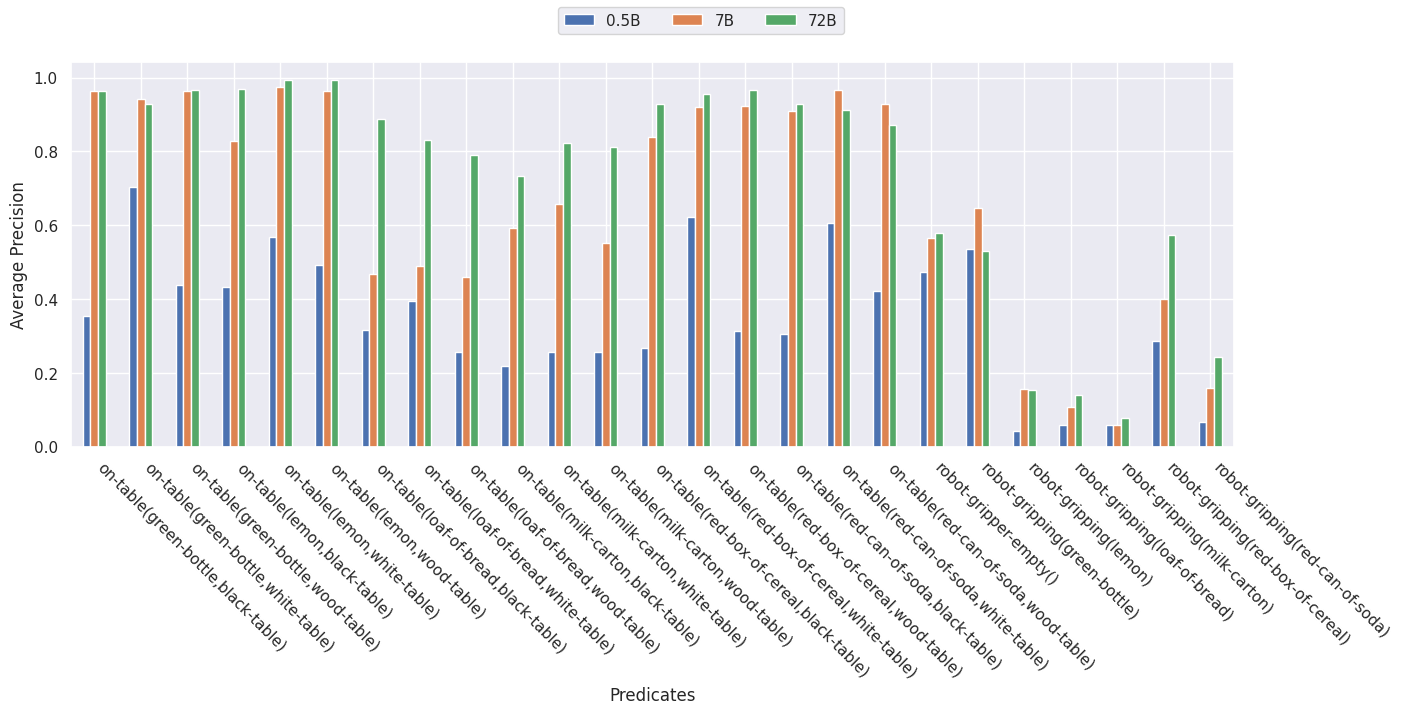

In [32]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average']).T
ap_pd = ap_pd[['0.5B', '7B', '72B']]

# ap_pd = ap_pd.T
# for col in ap_pd.columns:
#     new_col, args = col.split('(')
#     new_col += '\n' + args.split(')')[0]
#     ap_pd[new_col] = ap_pd[col]
#     ap_pd.drop(columns=col, inplace=True)
# ap_pd = ap_pd.T

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)
fig.savefig('AP_model_sizes.pdf', bbox_inches="tight")

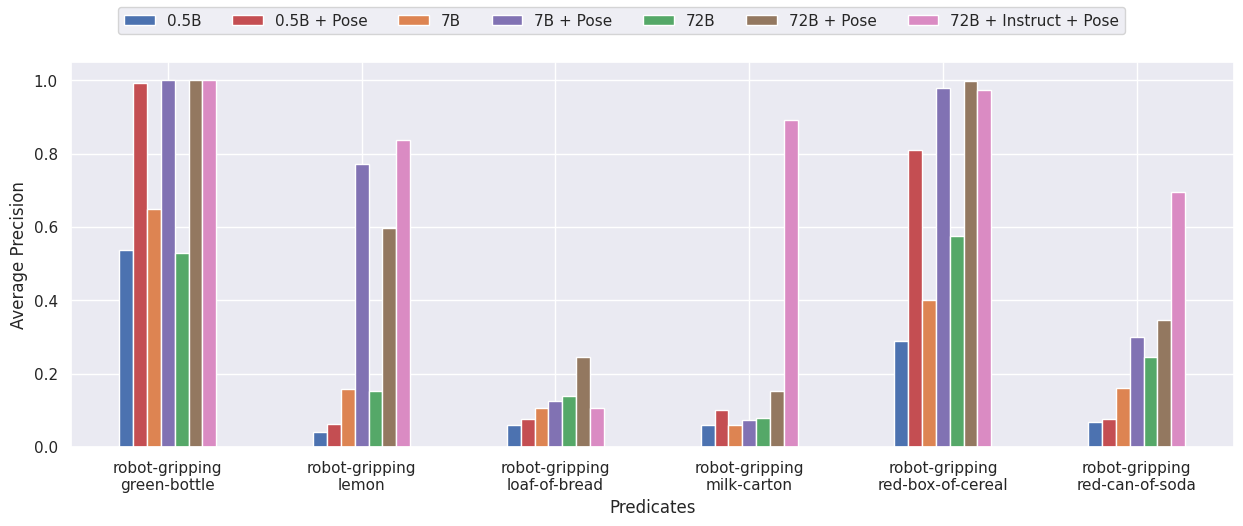

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
non_robot_preds = [predicate for predicate in next(iter(average_precision.values())) if not predicate.startswith('robot-gripping')]
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'] + non_robot_preds)
ap_pd = ap_pd.T[['0.5B', '0.5B + Pose', '7B', '7B + Pose', '72B', '72B + Pose', '72B + Instruct + Pose']]

ap_pd = ap_pd.T
for col in ap_pd.columns:
    new_col, args = col.split('(')
    new_col += '\n' + args.split(')')[0]
    ap_pd[new_col] = ap_pd[col]
    ap_pd.drop(columns=col, inplace=True)
ap_pd = ap_pd.T

ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns], rot=0)

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=7)
fig.savefig('AP_home_compare.pdf', bbox_inches="tight")

In [ ]:
predicate = 'robot-gripping(milk-carton)'

plt.figure()
plt.plot(recall['7B + Pose'][predicate], precision['7B + Pose'][predicate], label='7B + Pose', color=color_map['7B + Pose'])
plt.plot(recall['7B + Instruct + Pose'][predicate], precision['7B + Instruct + Pose'][predicate], label='7B + Instruct + Pose', color=color_map['7B + Instruct + Pose'])
plt.plot(recall['7B + Instruct-milk + Pose'][predicate], precision['7B + Instruct-milk + Pose'][predicate], label='7B + Instruct-milk + Pose', color=color_map['7B + Instruct-milk + Pose'])
plt.plot(recall['72B + Pose'][predicate], precision['72B + Pose'][predicate], label='72B + Pose', color=color_map['72B + Pose'])
plt.plot(recall['72B + Instruct + Pose'][predicate], precision['72B + Instruct + Pose'][predicate], label='72B + Instruct + Pose', color=color_map['72B + Instruct + Pose'])
plt.plot(recall['72B + Instruct-milk + Pose'][predicate], precision['72B + Instruct-milk + Pose'][predicate], label='72B + Instruct-milk + Pose', color=color_map['72B + Instruct-milk + Pose'])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.savefig('PRC grip milk.pdf', bbox_inches="tight")

In [ ]:
list(prec.values())[0].keys()

In [ ]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[['0.5B', '7B', '72B',
      '0.5B + Instruct', '7B + Instruct', '72B + Instruct',
      '0.5B + Pose', '7B + Pose', '72B + Pose',
      '0.5B + Instruct + Pose', '7B + Instruct + Pose', '72B + Instruct + Pose']]

table

In [ ]:
print(table.T.to_latex(float_format="%.2f"))

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))

width = 0.15

h1 = average_precision['72B-instruct-full + Pose'].values()
h2 = ap['72B-instruct-full + Pose'].values()
h3 = ap_cooc['72B-instruct-full + Pose'].values()

bars = average_precision['72B-instruct-full + Pose'].keys()
y_pos = np.arange(len(bars))

ax.bar(y_pos, h1, width=width, label='their AP')
ax.bar(y_pos + width, h2, width=width, label='my API')
ax.bar(y_pos + width*2, h3, width=width, label='my AP with COOC')

ax.set_xticks(y_pos + 0.375, bars, rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'])
ap_pd.T[['llama-llava-iter-images-05B', '7B', '72B', '72B-instruct']].plot.bar(legend=False, ax=ax)
ax1.set_xticks([])
ax1.set_ylabel('AP Score')

ax2.set_ylabel('AP Score')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=4, bbox_to_anchor=[0.1, 1.01])

In [ ]:
import pandas as pd

acc_pd = pd.DataFrame.from_dict(accuracy).T.drop(columns=['average'])
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5))

acc_pd.T[['llama-llava-iter-images-05B', '7B', '72B', '72B-instruct']].plot.bar(legend=False, ax=ax1)
ap_pd.T[['llama-llava-iter-images-05B', '7B', '72B', '72B-instruct']].plot.bar(legend=False, ax=ax2)

ax1.set_xticks([])
ax1.set_ylabel('AP Score')

ax2.set_ylabel('AP Score')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=4, bbox_to_anchor=[0.1, 1.01])

In [ ]:
import pandas as pd

acc_pd = pd.DataFrame.from_dict(accuracy).T.drop(columns='average')
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5))

acc_pd.T[['llama-llava-iter-images-05B', '7B', '72B']].plot.bar(legend=False, ax=ax1)
ap_pd.T[['llama-llava-iter-images-05B', '7B', '72B']].plot.bar(legend=False, ax=ax2)

ax1.set_xticks([])
ax1.set_ylabel('Accuracy')

ax2.set_ylabel('AP Score')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=3, bbox_to_anchor=[0.1, 1.01])

In [ ]:
import pandas as pd

acc_pd = pd.DataFrame.from_dict(accuracy).T.drop(columns='average')
ap_pd = pd.DataFrame.from_dict(average_precision).T.drop(columns=['micro average', 'macro average'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5))

acc_pd.T[['0.5B + Pose', '7B + Pose', '72B + Pose']].plot.bar(legend=False, ax=ax1)
ap_pd.T[['0.5B + Pose', '7B + Pose', '72B + Pose']].plot.bar(legend=False, ax=ax2)

ax1.set_xticks([])
ax1.set_ylabel('Accuracy')

ax2.set_ylabel('AP Score')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=3, bbox_to_anchor=[0.1, 1.01])

In [ ]:
acc_pd

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

acc_pd.T[['llama-llava-iter-images-05B', '7B', '72B']].plot.bar(ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=3, bbox_to_anchor=[0.1, 1.01])

In [ ]:
m = 'llama-llava-iter-images'

fig, ax = plt.subplots()

width=0.4
heights1 = prec[m].values()
heights2 = prec_cooc[m].values()
bars = prec[m].keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
ax.bar(y_pos, heights1, width=width, label='acc')
ax.bar(y_pos2, heights2, width=width, label='cooc')
ax.set_ylim((0, 1))

# Rotation of the bars names
ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90);

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

m = 'llama-llava-iter-images'

fig, ax = plt.subplots()

width=0.4
heights1 = rec[m].values()
heights2 = rec_cooc[m].values()
bars = prec[m].keys()
y_pos = range(len(bars))
y_pos2 = [p + width for p in y_pos]
ax.bar(y_pos, heights1, width=width, label='acc')
ax.bar(y_pos2, heights2, width=width, label='cooc')
ax.set_ylim((0, 1))

# Rotation of the bars names
ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90);

In [ ]:
len(heights2)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

def plot_compare_2_models(metric, m1, m2, l1, l2, title, xlabel, ylabel, color1, color2, ax = None):
    if ax is None:
        fig, ax = plt.subplots()
    
    width=0.4
    heights1 = metric[m1].values()
    heights2 = metric[m2].values()
    bars = metric[m1].keys()
    y_pos = range(len(bars))
    y_pos2 = [p + width for p in y_pos]
    ax.bar(y_pos, heights1, width=width, label=l1, color=color1)
    ax.bar(y_pos2, heights2, width=width, label=l2, color=color2)
    ax.set_ylim((0, 1))
    
    # Rotation of the bars names
    ax.set_xticks([pos + (width//2) for pos in y_pos], bars, rotation=90)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    

In [ ]:
import pandas as pd

df = pd.DataFrame.from_dict({k: v for k, v in average_precision.items() if k.startswith('home')})

In [ ]:
df.plot.bar(figsize=(22, 5))
plt.legend(loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))

width = 0.15

h1 = accuracy['default-7B'].values()
h2 = accuracy['llama-llava-iter-images'].values()
h3 = accuracy['llama-llava-iter-images-72B'].values()
h4 = accuracy['llama-llava-iter-images-with-milk-inst'].values()
h5 = accuracy['llama-llava-iter-images-with-milk-inst-72B'].values()

bars = accuracy['default-7B'].keys()
y_pos = np.arange(len(bars))

ax.bar(y_pos, h1, width=width, label='default')
ax.bar(y_pos + width, h2, width=width, label='iter')
ax.bar(y_pos + width*2, h3, width=width, label='iter72')
ax.bar(y_pos + width*3, h4, width=width, label='iter-milk')
ax.bar(y_pos + width*4, h5, width=width, label='iter-milk72')

ax.set_xticks(y_pos + 0.375, bars, rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))

width = 0.15

h1 = average_precision['default-7B'].values()
h2 = average_precision['llama-llava-iter-images'].values()
h3 = average_precision['llama-llava-iter-images-72B'].values()
h4 = average_precision['llama-llava-iter-images-with-milk-inst'].values()
h5 = average_precision['llama-llava-iter-images-with-milk-inst-72B'].values()

bars = average_precision['default-llama-llava'].keys()
y_pos = np.arange(len(bars))

ax.bar(y_pos, h1, width=width, label='default')
ax.bar(y_pos + width, h2, width=width, label='iter')
ax.bar(y_pos + width*2, h3, width=width, label='iter72')
ax.bar(y_pos + width*3, h4, width=width, label='iter-milk')
ax.bar(y_pos + width*4, h5, width=width, label='iter-milk72')

ax.set_xticks(y_pos + 0.375, bars, rotation=90)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=5, bbox_to_anchor=[0.1, 1.01])

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(accuracy, 'default-llama-llava', 'llama-llava-iter-images',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(average_precision, 'default-llama-llava', 'llama-llava-iter-images',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, ax = plt.subplots(figsize=(22, 5))
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'home-default',
                      'end action anywhere', 'end action at home', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#56ad74', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'home-default',
                      'end action anywhere', 'end action at home pose', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#56ad74', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'home',
#                       'end action anywhere', 'end action at home pose', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#56ad74', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different End Poses After Actions');

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-72B',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))
plot_compare_2_models(accuracy, 'llama-llava-iter-images-72B', 'llama-llava-iter-images-with-milk-inst-72B',
                      '7B model', '72B model', 'Accuracy', '', 'Prediction Accuracy', '#4c72b0', '#dd8453', ax=ax1)
plot_compare_2_models(average_precision, 'llama-llava-iter-images-72B', 'llama-llava-iter-images-with-milk-inst-72B',
                      '7B model', '72B model', 'Average Precision (AP)', '', 'Average Precision Score', '#4c72b0', '#dd8453', ax=ax2)
# plot_compare_2_models(auc, 'llama-llava-iter-images', 'llama-llava-iter-images-with-milk-inst',
#                       '7B model', '72B model', 'ROC Area Under the Curve', '', 'ROC AUC Score', '#4c72b0', '#dd8453', ax=ax3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, bbox_to_anchor=[0.1, 1.01])
fig.suptitle('Compare State Estimation with Different VQA Model Sizes')

In [ ]:
plot_compare_2_models(accuracy, 'llama-llava-iter-images', 'default-llama-llava',
                      '7B model', '72B model', 'Accuracy compare model sizes', 'predicate', 'prediction accuracy', '#4c72b0', '#56ad74')

In [ ]:
plot_compare_2_models(average_precision, 'llama-llava-iter-images', 'default-llama-llava',
                      '7B model', '72B model', 'Accuracy compare model sizes', 'predicate', 'prediction accuracy', '#4c72b0', '#56ad74')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()


heights = accuracy['llama-llava-iter-images'].values()
bars = accuracy['llama-llava-iter-images'].keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = average_precision['llama-llava-iter-images'].values()
bars = average_precision['llama-llava-iter-images'].keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
heights = auc.values()
bars = auc.keys()
y_pos = range(len(bars))
plt.bar(y_pos, heights)
plt.ylim((0, 1))

# Rotation of the bars names
plt.xticks(y_pos, bars, rotation=90);

In [ ]:
predicate = 'robot-gripping(milk-carton)'

plt.figure()
plt.ylim((-0.01, 1.01))
plt.title(f'PRC: {predicate}')
plt.plot(recall['home-iter72'][predicate], precision['home-iter72'][predicate])
plt.plot(recall['home-iter-milk72'][predicate], precision['home-iter-milk72'][predicate])
plt.show()

In [ ]:
predicate = 'robot-gripping(milk-carton)'

plt.figure()
plt.ylim((-0.01, 1.01))
plt.title(f'Precision on predicate {predicate}')
plt.plot(thresholds['home-iter72'][predicate], precision['home-iter72'][predicate], label='no instruct')
plt.plot(thresholds['home-iter-milk72'][predicate], precision['home-iter-milk72'][predicate], label='with instruct')
plt.xlabel('confidence threshold')
plt.ylabel('prediction precision')
plt.legend()
plt.show()

In [ ]:
predicate = 'robot-gripping(milk-carton)'

plt.figure()
plt.ylim((-0.01, 1.01))
plt.title(f'PRC: {predicate}')
plt.plot(thresholds['home-iter72'][predicate], precision['home-iter72'][predicate])
plt.plot(thresholds['home-iter-milk72'][predicate], precision['home-iter-milk72'][predicate])
plt.show()

In [ ]:
# precision = precision['llama-llava-iter-images-72B']
# recall = recall['llama-llava-iter-images-72B']
# thresholds = thresholds['llama-llava-iter-images-72B']

for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'precisions and recall: {predicate}')
    plt.plot(thresholds[predicate], precision[predicate], label='precision')
    plt.plot(thresholds[predicate], recall[predicate], label='recall')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'PRC: {predicate}')
    plt.plot(recall[predicate], precision[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'npv and specificity: {predicate}')
    plt.plot(thresholds[predicate], npv[predicate], label='npv')
    plt.plot(thresholds[predicate], specificity[predicate], label='specificity')
    plt.legend()
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'NSC: {predicate}')
    plt.plot(specificity[predicate], npv[predicate])
    plt.show()

In [ ]:
for predicate in precision:
    plt.figure()
    plt.ylim((-0.01, 1.01))
    plt.title(f'ROC: {predicate}')
    plt.plot(fpr[predicate], tpr[predicate])
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.show()

In [ ]:
all_renders, gts, preds = all_renders_home, gts_home, preds_home

In [ ]:
from semantic_state_estimator.utils.misc import remove_from_gpu_memory
se.vqa_model.clear_system_cache()
remove_from_gpu_memory(se)

In [ ]:
from semantic_state_estimator.semantic_state_estimator import SemanticEstimatorMultiImageRun
from PIL import Image
from llava.constants import DEFAULT_IMAGE_TOKEN

EXAMPLE = 'gw_grip_home'
LLAMA_ID = "meta-llama/Meta-Llama-3-70B-Instruct"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-7b-ov"
# LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov"
LLAVA_ID = "lmms-lab/llava-onevision-qwen2-72b-ov-sft"


additional_instructions="""The user will show you images of a simulated robot and ask questions about the state of the environment.
The milk carton is a clean white rectangular box with a triangular top.
When the robot is holding the milk carton it looks like there is a white rectangular object being pinched by the robot's gripper.
The red can of soda is a small red cylinder.
When the robot is holding the red can of soda it looks like there is a small red object that is enveloped by the robot's gripper.
The loaf of bread looks like a small brown box with two curves on one of its sides.
When the robot is gripping the loaf of bread it looks like there is a small brown object inside the robot gripper.
"""


se = SemanticEstimatorMultiImageRun(
    domain=f'examples/{EXAMPLE}/domain.pddl',
    problem=f'examples/{EXAMPLE}/problem.pddl',
    nl_converter_model_id=LLAMA_ID,
    vqa_model_id=LLAVA_ID,
    # additional_instructions=additional_instructions,
    # additional_images=additional_images
)

In [ ]:
additional_instructions="""The user will show you several images from different angles of the same simulated robot and ask questions about the state of the environment.
The robot has a black two-finger gripper. It is not holding anything """

additional_instructions="""The user will show you an image of a simulated robot and ask questions about the state of the environment.
The loaf of bread looks like a small brown box with two curves on one of its sides.
When the robot is gripping the loaf of bread it looks like there is a small brown object inside the robot gripper.
"""

In [ ]:
# remove instructions
se.vqa_model.system_prompt = se.vqa_model.system_prompt.split('\nAdditional Instructions and clarifications:')[0]

In [ ]:
# add instructions
se.vqa_model.system_prompt += f'\nAdditional Instructions and clarifications:\n{additional_instructions}'

In [ ]:
se.vqa_model.system_prompt = 'You are a helpful assistant.'

In [ ]:
print(se.vqa_model.system_prompt)

In [ ]:
se.vqa_model.clear_system_cache()

In [ ]:
# PREDICATE = 'on-table(milk-carton,white-table)'
PREDICATE = 'robot-gripper-empty()'
# PREDICATE = 'robot-gripping(milk-carton)'
# PREDICATE = 'robot-gripping(loaf-of-bread)'
# PREDICATE = 'on-table(loaf-of-bread,black-table)'
# PREDICATE = 'robot-gripping(red-can-of-soda)'
# PREDICATE = 'on-top-of(red_block,yellow_block)'

dps = []
for dp_name in gts.keys():
# for dp_name in preds['llama-llava-iter-images'].keys():
    if gts[dp_name][PREDICATE] != (preds['72B + Instruct'][dp_name][PREDICATE] > 0.5):
    # if gts[dp_name][PREDICATE] == True:
        dps.append(dp_name)
len(dps)

In [ ]:
se.vqa_model.tokenizer.decode(1512)

In [ ]:
[k for k in se.vqa_model.tokenizer.vocab if 'decide' in k]

In [ ]:
se.vqa_model.tokenizer(['moot'])

In [ ]:
from PIL import Image

dp_name = np.random.choice(dps)

img = Image.fromarray(
    all_renders[dp_name]['frontview']
)
print(gts[dp_name][PREDICATE])
img

In [ ]:
se.vqa_model.generate([img], ["describe the scene in detail. Put extra attention on the robot's gripper in detail. Is the robot holding anything?"])

In [ ]:
gts[dp_name]['robot-gripping(milk-carton)']

In [ ]:
preds['72B + Instruct'][dp_name]['robot-gripping(red-can-of-soda)']

In [ ]:
# se.estimate_state_par([
#     Image.fromarray(img_arr)
#     for img_arr in all_renders[dp_name].values()
# ], batch_size=16)
se.estimate_state([
    Image.fromarray(all_renders[dp_name]['frontview'])
])

In [ ]:
from tqdm.auto import tqdm
imgs = {
    k: Image.fromarray(img_arr)
    for k, img_arr in all_renders[dp_name].items()
}

# np.mean([
#     se.logits_to_yes_no_probs(se.vqa_model([img], ["Is the robot's gripper currently empty?"])[:, -1].float()).item()
#     for img in tqdm(imgs.values())
# ])
pred_per_img = {
    k: se.logits_to_yes_no_probs(se.vqa_model([img], ["Is the robot currently holding the loaf of bread?"])[:, -1].float()).item()
    for k, img in tqdm(imgs.items())
}
display(pred_per_img)
"mean", np.mean(list(pred_per_img.values()))

In [ ]:
se.logits_to_yes_no_probs(se.vqa_model(list(imgs.values())[:5], ["Is the robot's gripper currently empty?"])[:, -1].float()).item()

In [ ]:
from tqdm.auto import tqdm
imgs = [
    Image.fromarray(img_arr)
    for img_arr in all_renders[dp_name].values()
]

np.mean([
    se.logits_to_yes_no_probs(se.vqa_model([img], ["Is the red can of soda in the robot's gripper jaws?"])[:, -1].float()).item()
    for img in tqdm(imgs)
])

In [ ]:
se.vqa_model.generate(list(imgs.values())[:3], "what colors are the tables?")

In [ ]:
dp_name

In [ ]:
'hello'.split('l')

In [ ]:
from PIL import Image
dp_name = "data_point_9"
imgs = [
    Image.fromarray(img_arr)
    for img_arr in all_renders[dp_name].values()
]
imgs[0]

In [ ]:
for img in imgs:
    display(img)